In [1]:
### First read both revcomp and forward var effects
import pandas as pd

forward = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/opentargets_model/gosai/k562_gosai.csv.gz", compression="gzip")
reverse = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/opentargets_model/gosai/k562_gosai_revcomp.csv.gz", compression="gzip")

# print(forward.head(1))

### Have to switch the column labels for the forward df
rename_dict = {}
for col in forward.columns:
    if col.startswith("offset_"):
        pos = int(col.split("_")[1])
        flipped_col = f"offset_{-pos}"
        rename_dict[col] = flipped_col

# Apply the renaming
forward = forward.rename(columns=rename_dict)
# print(forward.head(1))

In [2]:
### Now change the values
offset_cols = [col for col in forward.columns if col.startswith("offset_")]
forward[offset_cols] = forward[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
forward["seq_id"] = ["seq_" + str(i + 1) for i in range(len(forward))]

reverse[offset_cols] = reverse[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
reverse["seq_id"] = ["seq_rev_" + str(i + 1) for i in range(len(reverse))]

/tmp/ipykernel_694329/2042737668.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  forward[offset_cols] = forward[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)
/tmp/ipykernel_694329/2042737668.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  reverse[offset_cols] = reverse[offset_cols].applymap(lambda x: float(x.strip("[]")) if isinstance(x, str) else x)


In [3]:
### Combine and filter out the rows
forward["strand"] = "forward"
reverse["strand"] = "reverse"
combined = pd.concat([forward, reverse], ignore_index=True)
offset_cols = [col for col in combined.columns if col.startswith("offset_")]
filtered = combined[combined[offset_cols].apply(
    lambda row: (row > 0.50).any() or (row < -0.50).any(), axis=1)]

print(len(filtered))

21303


In [4]:
filtered.head()

,offset_90,offset_80,offset_60,offset_40,offset_20,offset_0,offset_-20,offset_-40,offset_-60,offset_-80,offset_-90,seq_id,strand
4,0.635050,0.770286,0.926143,1.027890,0.916269,0.922576,0.893546,0.946532,0.844249,0.404994,0.757836,seq_5,forward
17,-0.349134,-0.281905,-0.189614,-0.214767,-0.216436,-0.168641,-0.214483,-0.111152,0.010298,-0.190719,-1.091787,seq_18,forward
19,-0.097042,-0.364475,-0.365366,-0.494047,-0.530584,-0.443489,-0.361047,-0.342817,-0.249859,-0.087021,-0.011963,seq_20,forward
26,-0.816010,-0.833008,-1.100477,-1.152006,-1.085007,-0.987864,-1.458874,-1.305679,-1.473468,-1.294219,-0.827940,seq_27,forward
43,0.408620,0.202143,0.575531,0.541331,0.505679,0.384498,0.255544,0.257842,0.204843,0.030629,0.023673,seq_44,forward


In [5]:
filtered[offset_cols] = filtered[offset_cols].apply(lambda row: row / row.loc[row.abs().idxmax()], axis=1)
filtered.head(2)

/tmp/ipykernel_694329/18384593.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered[offset_cols] = filtered[offset_cols].apply(lambda row: row / row.loc[row.abs().idxmax()], axis=1)


,offset_90,offset_80,offset_60,offset_40,offset_20,offset_0,offset_-20,offset_-40,offset_-60,offset_-80,offset_-90,seq_id,strand
4,0.617819,0.749386,0.901013,1.000000,0.891407,0.897543,0.869301,0.920850,0.821341,0.394005,0.737274,seq_5,forward
17,0.319782,0.258205,0.173673,0.196711,0.198240,0.154463,0.196451,0.101808,-0.009433,0.174685,1.000000,seq_18,forward


/arc/project/st-cdeboer-1/sambina/miniconda3/envs/dream_rocky/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


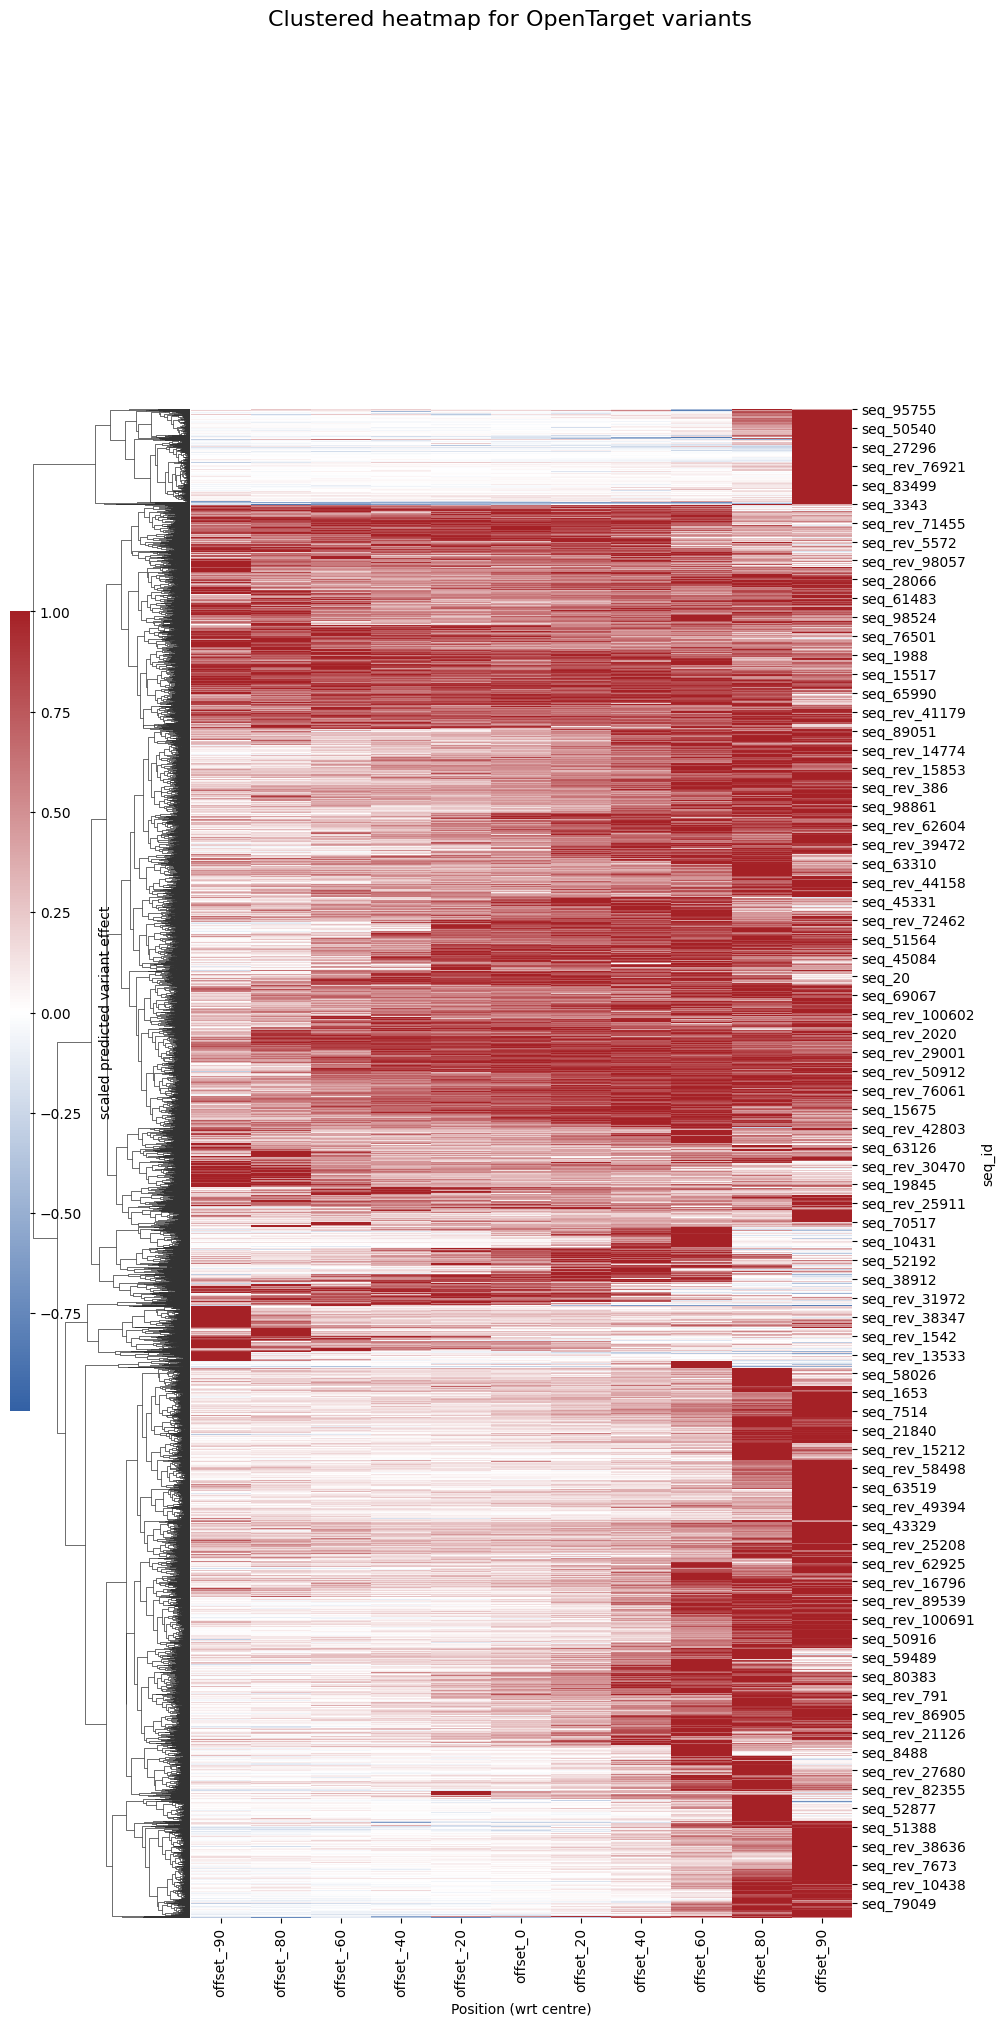

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


# new_offset_cols = sorted(renamed_cols.values(), key=lambda x: int(x.split('_')[1]))
new_offset_cols = sorted(offset_cols, key=lambda x: int(x.split('_')[1]))

heatmap_data = filtered[new_offset_cols]
heatmap_data.index = filtered['seq_id']  

colors = ['#3361A5', '#ffffff', '#A52126']

cmap = LinearSegmentedColormap.from_list('custom_red_black_blue', colors, N=256)

g = sns.clustermap(
    heatmap_data,    
    cmap=cmap,
    metric='euclidean', 
    method='complete',
    figsize=(10,20),
    annot=False,           
    col_cluster=False,    
    z_score=None,
    standard_scale=None
)

g.cax.set_position([0, .3, .02, .4])
g.cax.set_ylabel("scaled predicted variant effect", rotation=90, labelpad=12)

g.ax_heatmap.set_xlabel("Position (wrt centre)")
g.ax_heatmap.set_ylabel("seq_id")
g.fig.suptitle("Clustered heatmap for OpenTarget variants", y=1.001, fontsize=16, ha='center')
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/cluster/heatmap_OT.svg", format="svg")
plt.show()
